In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
drive.mount('/content/drive')
df = pd.read_csv('/content/online vs store shopping dataset.csv')
df.shape
df.head()
df.info()

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int

In [ ]:

#figue 1
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
target_counts = df['shopping_preference'].value_counts()
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=90)
plt.title('Figure 1A: Target Variable - Shopping Preference', fontsize=14)
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='shopping_preference', order=target_counts.index, palette='viridis')
ax = sns.countplot(data=df, x='shopping_preference', order=target_counts.index, palette='viridis')
ax.bar_label(ax.containers[0])
plt.title('Figure 1B: Target Variable Count (Severe Imbalance)', fontsize=14)
plt.tight_layout()
plt.show()


# figure 2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
# age
sns.histplot(df['age'], bins=30, kde=True, color='purple', ax=axes[0])
axes[0].set_title('Figure 2A: Age Distribution', fontsize=12)

# sex
sns.countplot(data=df, x='gender', order=df['gender'].value_counts().index, palette='Set2', ax=axes[1])
axes[1].bar_label(axes[1].containers[0])
axes[1].set_title('Figure 2B: Gender Distribution (Ethical Check)', fontsize=12)

# city tier
sns.countplot(data=df, x='city_tier', order=df['city_tier'].value_counts().index, palette='Set3', ax=axes[2])
axes[2].bar_label(axes[2].containers[0])
axes[2].set_title('Figure 2C: City Tier Distribution', fontsize=12)
fig.delaxes(axes[3])
plt.tight_layout()
plt.show()


# figure 3
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes = axes.flatten()
sns.histplot(df['monthly_income'], bins=30, kde=True, color='coral', ax=axes[0])
axes[0].set_title('Figure 3A: Monthly Income Distribution', fontsize=12)
axes[0].set_xlabel('Monthly Income')
axes[0].set_ylabel('Count')
sns.histplot(df['avg_online_spend'], bins=30, kde=True, color='skyblue', ax=axes[1])
axes[1].set_title('Figure 3B: Avg Online Spend Distribution', fontsize=12)
axes[1].set_xlabel('Average Online Spend')
sns.histplot(df['avg_store_spend'], bins=30, kde=True, color='lightgreen', ax=axes[2])
axes[2].set_title('Figure 3C: Avg Store Spend Distribution', fontsize=12)
axes[2].set_xlabel('Average Store Spend')
fig.delaxes(axes[3])

plt.tight_layout()
plt.show()

# figur 4 heatmap
plt.figure(figsize=(12, 8))
selected_cols = ['age', 'monthly_income', 'tech_savvy_score', 'online_payment_trust_score',
                 'discount_sensitivity', 'monthly_online_orders', 'monthly_store_visits']
corr_matrix = df[selected_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Figure 3: Correlation Heatmap of Key Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
df_processed = df.copy()

# processing null
num_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns
df_processed[num_cols] = df_processed[num_cols].fillna(df_processed[num_cols].median())

# Label Encoding
# 'Store', 'Online', 'Hybrid' → '0, 1, 2'
le = LabelEncoder()
df_processed['shopping_preference'] = le.fit_transform(df_processed['shopping_preference'])

# Mapping
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(mapping)

# One-Hot Encoding
categorical_cols = ['gender', 'city_tier']
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)


X = df_processed.drop('shopping_preference', axis=1)
y = df_processed['shopping_preference']
# divide dataset Train 70%, Validation 15%, Test 15%
X_train, X_temp, y_train, y_temp = train_test_split(X, y, =test_size0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Standardization
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"Train: {X_train_scaled.shape}")
print(f"Validation: {X_val_scaled.shape}")
print(f"Test: {X_test_scaled.shape}")

{'Hybrid': 0, 'Online': 1, 'Store': 2}
Train: (8252, 26)
Validation: (1768, 26)
Test: (1769, 26)


In [ ]:
# =========================
# Task 2: ANN Model Building
# =========================

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

# random seed
tf.random.set_seed(42)

# build model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.30),

    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.25),

    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.20),

    Dense(3, activation='softmax')
])

# compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# model summary
model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,659 (57.26 KB)

 Trainable params: 14,275 (55.76 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# class weights for imbalanced dataset
class_counts = pd.Series(y_train).value_counts().sort_index()

print("Class counts:")
print(class_counts)

# Total sample
n_samples = len(y_train)

# The number of classifications
n_classes = len(class_counts)

# class weight
class_weight = {}

for cls, count in class_counts.items():
    class_weight[cls] = n_samples / (n_classes * count)

print("Class weight dictionary:")
print(class_weight)


Class counts:
shopping_preference
0     258
1     823
2    7171
Name: count, dtype: int64
Class weight dictionary:
{0: 10.661498708010337, 1: 3.3422438234102874, 2: 0.38358202017384835}


In [ ]:
# Define class weight
class_weight = {
    0: 10.66,   # Hybrid
    1: 3.34,    # Online
    2: 0.38     # Store
}

# callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# train model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4976 - loss: 1.3543 - val_accuracy: 0.6544 - val_loss: 0.9657 - learning_rate: 0.0010
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6707 - loss: 1.0189 - val_accuracy: 0.7144 - val_loss: 0.7975 - learning_rate: 0.0010
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7359 - loss: 0.9144 - val_accuracy: 0.7370 - val_loss: 0.7104 - learning_rate: 0.0010
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7729 - loss: 0.8609 - val_accuracy: 0.7675 - val_loss: 0.6482 - learning_rate: 0.0010
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7960 - loss: 0.8033 - val_accuracy: 0.7919 - val_loss: 0.6134 - learning_rate: 0.0010
Epoch 6/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8222 - loss: 0.7507 - val_accuracy: 0.8331 - val_loss: 0.5020 - learning_rate: 0.0010
Epoch 7/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8349 - loss: 0.

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Confusion Matrix:
[[  43   11    1]
 [   8  169    0]
 [  15    1 1521]]

Macro F1-score: 0.8831

Classification Report:
              precision    recall  f1-score   support

           0     0.6515    0.7818    0.7107        55
           1     0.9337    0.9548    0.9441       177
           2     0.9993    0.9896    0.9944      1537

    accuracy                         0.9796      1769
   macro avg     0.8615    0.9087    0.8831      1769
weighted avg     0.9820    0.9796    0.9806      1769



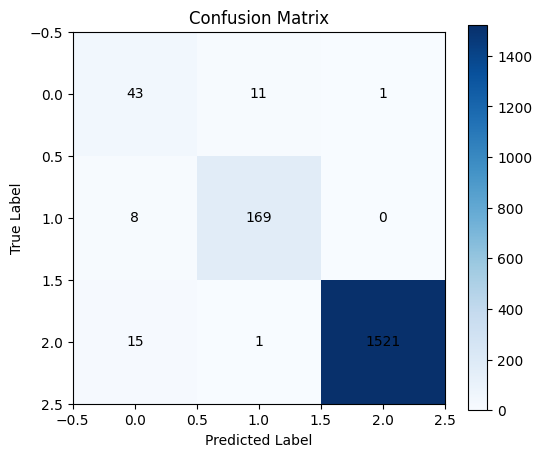

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import numpy as np

# predict class probabilities
y_prob = model.predict(X_test_scaled)

# convert probabilities to predicted class labels
y_pred = np.argmax(y_prob, axis=1)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# macro f1-score
macro_f1 = f1_score(y_test, y_pred, average='macro')
print("\nMacro F1-score:", round(macro_f1, 4))

# precision / recall / f1
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.show()

In [ ]:
#TASK 3
# Activation function 1: ReLU
tf.random.set_seed(42)
model_relu = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.30),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.25),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.20),
    Dense(3, activation='softmax')
])
model_relu.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_relu = model_relu.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, batch_size=32, class_weight=class_weight, callbacks=[early_stop, reduce_lr], verbose=1)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


258/258 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4782 - loss: 1.2729 - val_accuracy: 0.6544 - val_loss: 0.9658 - learning_rate: 0.0010
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7162 - loss: 0.9436 - val_accuracy: 0.7534 - val_loss: 0.7265 - learning_rate: 0.0010
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7768 - loss: 0.8584 - val_accuracy: 0.7647 - val_loss: 0.7065 - learning_rate: 0.0010
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8020 - loss: 0.7938 - val_accuracy: 0.7986 - val_loss: 0.6187 - learning_rate: 0.0010
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8233 - loss: 0.7555 - val_accuracy: 0.8241 - val_loss: 0.5609 - learning_rate: 0.0010
Epoch 6/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8404 - loss: 0.7000 - val_accuracy: 0.8331 - val_loss: 0.5396 - learning_rate: 5.0000e-04
Epoch 7/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8451 - loss: 0.6929 - v

In [ ]:
# Activation function 2: ELU
tf.random.set_seed(42)
model_elu = Sequential([
    Dense(128, activation='elu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.30),
    Dense(64, activation='elu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.25),
    Dense(32, activation='elu', kernel_regularizer=l2(0.001)),
    Dropout(0.20),
    Dense(3, activation='softmax')
])
model_elu.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_elu = model_elu.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, batch_size=32, class_weight=class_weight, callbacks=[early_stop, reduce_lr], verbose=1)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5253 - loss: 1.3434 - val_accuracy: 0.7087 - val_loss: 0.8105 - learning_rate: 0.0010
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7158 - loss: 0.9983 - val_accuracy: 0.7540 - val_loss: 0.7258 - learning_rate: 0.0010
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7608 - loss: 0.8970 - val_accuracy: 0.7777 - val_loss: 0.6595 - learning_rate: 0.0010
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7912 - loss: 0.8338 - val_accuracy: 0.8167 - val_loss: 0.5917 - learning_rate: 0.0010
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8021 - loss: 0.8154 - val_accuracy: 0.8133 - val_loss: 0.5730 - learning_rate: 0.0010
Epoch 6/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8186 - loss: 0.7810 - val_accuracy: 0.8292 - val_loss: 0.5418 - learning_rate: 5.0000e-04
Epoch 7/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8213 - loss: 0.7723 - v

In [ ]:
# Activation function 3: Swish
tf.random.set_seed(42)
model_swish = Sequential([
    Dense(128, activation='swish', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.30),
    Dense(64, activation='swish', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.25),
    Dense(32, activation='swish', kernel_regularizer=l2(0.001)),
    Dropout(0.20),
    Dense(3, activation='softmax')
])
model_swish.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_swish = model_swish.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, batch_size=32, class_weight=class_weight, callbacks=[early_stop, reduce_lr], verbose=1)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5002 - loss: 1.2353 - val_accuracy: 0.6640 - val_loss: 0.8810 - learning_rate: 0.0010
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7266 - loss: 0.9361 - val_accuracy: 0.7330 - val_loss: 0.7175 - learning_rate: 0.0010
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7825 - loss: 0.8311 - val_accuracy: 0.7919 - val_loss: 0.6215 - learning_rate: 0.0010
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8136 - loss: 0.7663 - val_accuracy: 0.8071 - val_loss: 0.5425 - learning_rate: 0.0010
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8243 - loss: 0.7585 - val_accuracy: 0.8156 - val_loss: 0.5367 - learning_rate: 0.0010
Epoch 6/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8391 - loss: 0.7016 - val_accuracy: 0.8343 - val_loss: 0.5124 - learning_rate: 5.0000e-04
Epoch 7/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8434 - loss: 0.6783 - v

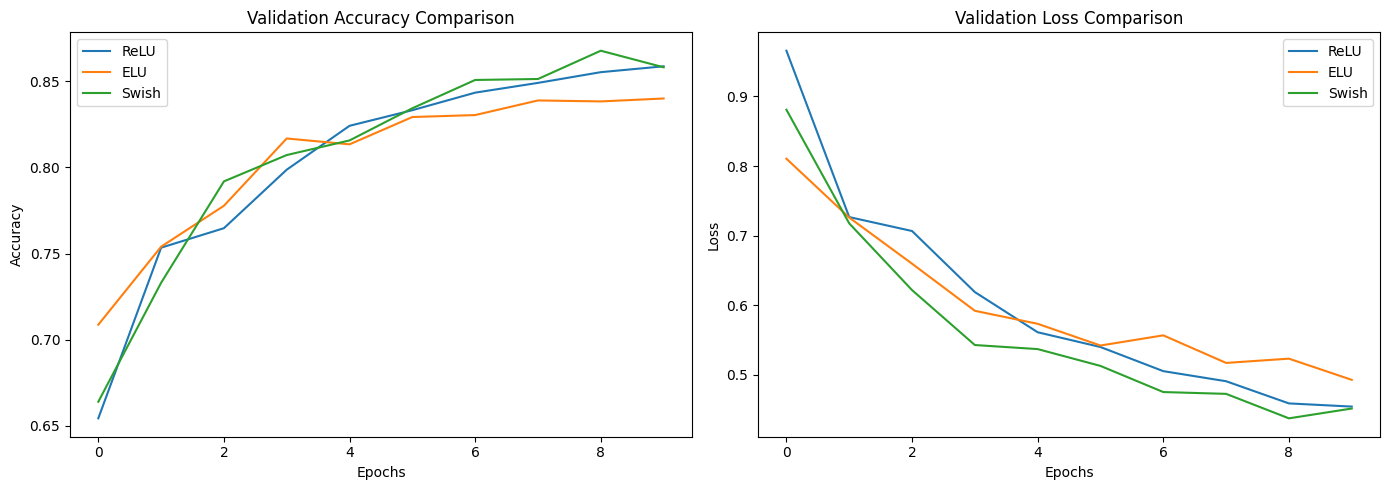

In [ ]:
# ================= Activation Function Comparison Plot =================
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# Validation Accuracy Comparison
plt.subplot(1,2,1)
plt.plot(history_relu.history['val_accuracy'], label='ReLU')
plt.plot(history_elu.history['val_accuracy'], label='ELU')
plt.plot(history_swish.history['val_accuracy'], label='Swish')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Validation Loss Comparison
plt.subplot(1,2,2)
plt.plot(history_relu.history['val_loss'], label='ReLU')
plt.plot(history_elu.history['val_loss'], label='ELU')
plt.plot(history_swish.history['val_loss'], label='Swish')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ================= Final Performance Results =================
acc_relu = max(history_relu.history['val_accuracy'])
acc_elu = max(history_elu.history['val_accuracy'])
acc_swish = max(history_swish.history['val_accuracy'])

loss_relu = min(history_relu.history['val_loss'])
loss_elu = min(history_elu.history['val_loss'])
loss_swish = min(history_swish.history['val_loss'])

print("===== Activation Function Comparison Results =====")
print(f"ReLU   Best Accuracy: {acc_relu:.4f} | Minimum Loss: {loss_relu:.4f}")
print(f"ELU    Best Accuracy: {acc_elu:.4f} | Minimum Loss: {loss_elu:.4f}")
print(f"Swish  Best Accuracy: {acc_swish:.4f} | Minimum Loss: {loss_swish:.4f}")

===== Activation Function Comparison Results =====
ReLU   Best Accuracy: 0.8586 | Minimum Loss: 0.4540
ELU    Best Accuracy: 0.8399 | Minimum Loss: 0.4924
Swish  Best Accuracy: 0.8676 | Minimum Loss: 0.4370


In [ ]:
print("\nClassification Report (All Folds Combined):")
print("                    Predicted Label")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=['Hybrid', 'Online', 'Store'],
    digits=2
))


Classification Report (All Folds Combined):
                    Predicted Label
              precision    recall  f1-score   support

      Hybrid       0.40      0.73      0.52       314
      Online       0.91      0.92      0.92       999
       Store       1.00      0.97      0.98      8707

    accuracy                           0.96     10020
   macro avg       0.77      0.87      0.81     10020
weighted avg       0.97      0.96      0.96     10020



In [ ]:
# =========================
# Task 4: K-Fold Cross-Validation
# =========================
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, mean_squared_error, mean_absolute_error, confusion_matrix, accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Ensure the mapping is correct
class_names = ['Hybrid', 'Online', 'Store']

# combine the data
X_kfold = pd.concat([X_train, X_val])
y_kfold = pd.concat([y_train, y_val])

In [ ]:
# define and buld the model
def build_model():
    tf.random.set_seed(42)
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.30),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.25),
        Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.20),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
# set up K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_y_true = []
all_y_pred = []
accuracies, f1_scores, rmses, maes = [], [], [], []

In [ ]:
# Start cross-validation loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_kfold, y_kfold), 1):
    print(f"\n--- training {fold}/5 fold ---")

    X_tr = X_kfold.iloc[train_idx]
    X_va = X_kfold.iloc[val_idx]
    y_tr = y_kfold.iloc[train_idx]
    y_va = y_kfold.iloc[val_idx]

    # Independent standardization for each fold
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_va_scaled = scaler.transform(X_va)

    early_stop_fold = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr_fold = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

    fold_model = build_model()
    fold_model.fit(
        X_tr_scaled, y_tr,
        validation_data=(X_va_scaled, y_va),
        epochs=50,
        batch_size=64,
        class_weight=class_weight,
        callbacks=[early_stop_fold, reduce_lr_fold],
        verbose=0
    )

    # predict and result
    y_prob = fold_model.predict(X_va_scaled, verbose=0)
    y_pred_fold = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_va, y_pred_fold)
    accuracies.append(acc)
    f1_scores.append(f1_score(y_va, y_pred_fold, average='macro'))
    rmses.append(np.sqrt(mean_squared_error(y_va, y_pred_fold)))
    maes.append(mean_absolute_error(y_va, y_pred_fold))

    all_y_true.extend(y_va)
    all_y_pred.extend(y_pred_fold)

    print(f"the accuracy of {fold} fold: {acc:.4f}")


--- training 1/5 fold ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


the accuracy of 1 fold: 0.9576

--- training 2/5 fold ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


the accuracy of 2 fold: 0.9556

--- training 3/5 fold ---


...

the accuracy of 3 fold: 0.9716

--- training 4/5 fold ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


the accuracy of 4 fold: 0.9706

--- training 5/5 fold ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


the accuracy of 5 fold: 0.9676


In [ ]:
# print the final result
print("\n" + "="*30)
print(f"5-Fold avg accuracy: {np.mean(accuracies):.4f} (+/- {np.std(accuracies):.4f})")
print(f"avg Macro F1  : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print("="*30)


5-Fold avg accuracy: 0.9646 (+/- 0.0067)
avg Macro F1  : 0.8204 ± 0.0209


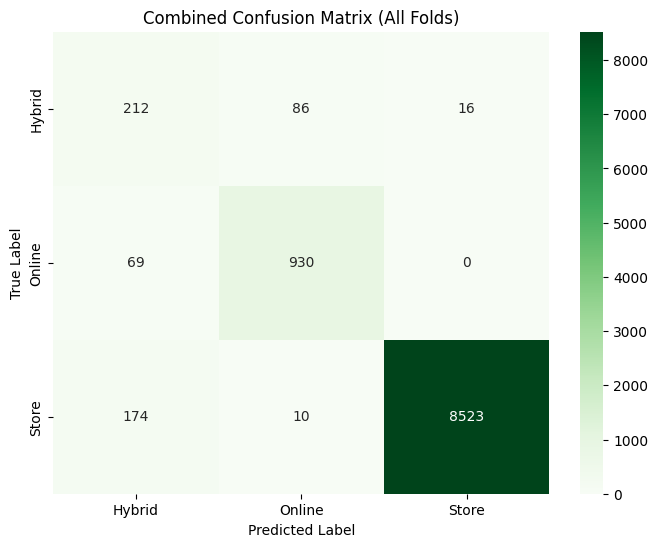

In [ ]:
# Draw the confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_y_true, all_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Combined Confusion Matrix (All Folds)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Print classification report
print("\nClassification Report (All Folds Combined):")
print("                    Predicted Label")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=class_names,
    digits=2
))


Classification Report (All Folds Combined):
                    Predicted Label
              precision    recall  f1-score   support

      Hybrid       0.47      0.68      0.55       314
      Online       0.91      0.93      0.92       999
       Store       1.00      0.98      0.99      8707

    accuracy                           0.96     10020
   macro avg       0.79      0.86      0.82     10020
weighted avg       0.97      0.96      0.97     10020



In [ ]:
# build up data set for ethical analysis
ethics_df = X_test.copy().reset_index(drop=True)
ethics_df["y_true"] = pd.Series(y_test).reset_index(drop=True)
ethics_df["y_pred"] = pd.Series(y_pred).reset_index(drop=True)

ethics_df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender_Male,gender_Other,city_tier_Tier 2,city_tier_Tier 3,y_true,y_pred
0,42,100637,5.1,4,5.3,3,7,44,18,26016,...,9,1,8,6,True,False,False,False,2,2
1,65,167402,7.9,14,3.5,4,5,16,13,136218,...,5,7,10,8,False,False,False,False,2,2
2,51,54950,3.1,6,1.5,5,9,39,18,118098,...,8,6,9,6,True,False,False,True,2,2
3,26,123621,2.6,3,2.6,3,5,24,5,145807,...,2,5,6,7,False,False,False,True,1,1
4,63,109279,5.5,11,2.5,4,6,40,15,70212,...,5,4,8,7,False,True,True,False,2,2


In [ ]:
gender_dummy_cols = [c for c in ethics_df.columns if c.startswith("gender_")]
print(gender_dummy_cols)

if len(gender_dummy_cols) > 0:
    raw_gender_values = sorted(df["gender"].dropna().astype(str).unique())
    kept_gender_values = [c.replace("gender_", "") for c in gender_dummy_cols]
    base_gender = [g for g in raw_gender_values if g not in kept_gender_values][0]

    def get_gender_group(row):
        for c in gender_dummy_cols:
            if row[c] == 1:
                return c.replace("gender_", "")
        return base_gender

    ethics_df["gender_group"] = ethics_df.apply(get_gender_group, axis=1)

ethics_df[["gender_group"]].head()

['gender_Male', 'gender_Other', 'gender_group']


,gender_group
0,Male
1,Female
2,Male
3,Female
4,Other


In [ ]:
# group the city tier
city_dummy_cols = [c for c in ethics_df.columns if c.startswith("city_tier_")]
print(city_dummy_cols)

if len(city_dummy_cols) > 0:
    raw_city_values = sorted(df["city_tier"].dropna().astype(str).unique())
    kept_city_values = [c.replace("city_tier_", "") for c in city_dummy_cols]
    base_city = [g for g in raw_city_values if g not in kept_city_values][0]

    def get_city_group(row):
        for c in city_dummy_cols:
            if row[c] == 1:
                return c.replace("city_tier_", "")
        return base_city

    ethics_df["city_group"] = ethics_df.apply(get_city_group, axis=1)

ethics_df[["city_group"]].head()

['city_tier_Tier 2', 'city_tier_Tier 3']


,city_group
0,Tier 1
1,Tier 1
2,Tier 3
3,Tier 3
4,Tier 2


In [ ]:
# group the age, income
if "age" in ethics_df.columns:
    ethics_df["age_group"] = pd.cut(
        ethics_df["age"],
        bins=[0, 25, 40, 60, 120],
        labels=["18-25", "26-40", "41-60", "60+"],
        include_lowest=True
    )

if "monthly_income" in ethics_df.columns:
    ethics_df["income_group"] = pd.qcut(
        ethics_df["monthly_income"],
        q=4,
        labels=["Low", "Mid-Low", "Mid-High", "High"],
        duplicates="drop"
    )

ethics_df[["age", "age_group", "monthly_income", "income_group"]].head()

,age,age_group,monthly_income,income_group
0,42,41-60,100637,Mid-Low
1,65,60+,167402,Mid-High
2,51,41-60,54950,Low
3,26,26-40,123621,Mid-Low
4,63,60+,109279,Mid-Low


In [ ]:

ALL_LABELS = sorted(ethics_df["y_true"].unique())

def subgroup_metrics(df_in, group_col):
    rows = []

    for group, subdf in df_in.groupby(group_col, dropna=False):
        rows.append({
            "group": group,
            "n": len(subdf),
            "accuracy": round(accuracy_score(subdf["y_true"], subdf["y_pred"]), 4),
            "macro_f1": round(
                f1_score(subdf["y_true"], subdf["y_pred"], labels=ALL_LABELS, average="macro", zero_division=0), 4
            ),
            "precision_macro": round(
                precision_score(subdf["y_true"], subdf["y_pred"], labels=ALL_LABELS, average="macro", zero_division=0), 4
            ),
            "recall_macro": round(
                recall_score(subdf["y_true"], subdf["y_pred"], labels=ALL_LABELS, average="macro", zero_division=0), 4
            ),
            "error_rate": round((subdf["y_true"] != subdf["y_pred"]).mean(), 4)
        })

    return pd.DataFrame(rows).sort_values(by="n", ascending=False).reset_index(drop=True)

In [ ]:
#gender result
gender_results = subgroup_metrics(ethics_df, "gender_group")
print("Gender subgroup performance ")
display(gender_results)
#age result
age_results = subgroup_metrics(ethics_df, "age_group")
print("Age subgroup performance")
display(age_results)
#city tier result
city_results = subgroup_metrics(ethics_df, "city_group")
print("City-tier subgroup performance")
display(city_results)
#income result
income_results = subgroup_metrics(ethics_df, "income_group")
print("Income subgroup performance")
display(income_results)

Gender subgroup performance 


,group,n,accuracy,macro_f1,precision_macro,recall_macro,error_rate
0,Male,620,0.9823,0.8530,0.8343,0.8744,0.0177
1,Female,589,0.9796,0.8855,0.8797,0.8917,0.0204
2,Other,560,0.9768,0.8967,0.8652,0.9442,0.0232


Age subgroup performance


/tmp/ipykernel_2694/1436359269.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, subdf in df_in.groupby(group_col, dropna=False):


,group,n,accuracy,macro_f1,precision_macro,recall_macro,error_rate
0,41-60,577,0.9809,0.8886,0.8828,0.8959,0.0191
1,60+,540,0.9759,0.8675,0.8280,0.9445,0.0241
2,26-40,423,0.9811,0.8918,0.8804,0.9055,0.0189
3,18-25,229,0.9825,0.8879,0.8758,0.9014,0.0175


City-tier subgroup performance


,group,n,accuracy,macro_f1,precision_macro,recall_macro,error_rate
0,Tier 1,615,0.9724,0.8642,0.8396,0.8974,0.0276
1,Tier 3,610,0.9836,0.8803,0.8605,0.9023,0.0164
2,Tier 2,544,0.9835,0.9088,0.8941,0.9251,0.0165


/tmp/ipykernel_2694/1436359269.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, subdf in df_in.groupby(group_col, dropna=False):


Income subgroup performance


,group,n,accuracy,macro_f1,precision_macro,recall_macro,error_rate
0,Low,443,0.9774,0.8727,0.8626,0.8846,0.0226
1,Mid-Low,442,0.9842,0.8936,0.8734,0.9200,0.0158
2,Mid-High,442,0.9864,0.9268,0.8984,0.9638,0.0136
3,High,442,0.9706,0.8410,0.8125,0.8740,0.0294


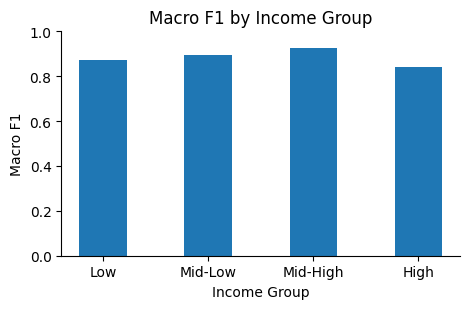

In [ ]:
#income subgroup visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(4.8, 3.2))
plt.bar(
    income_results["group"].astype(str),
    income_results["macro_f1"],
    width=0.45
)

plt.title("Macro F1 by Income Group", fontsize=12)
plt.xlabel("Income Group", fontsize=10)
plt.ylabel("Macro F1", fontsize=10)
plt.ylim(0, 1)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

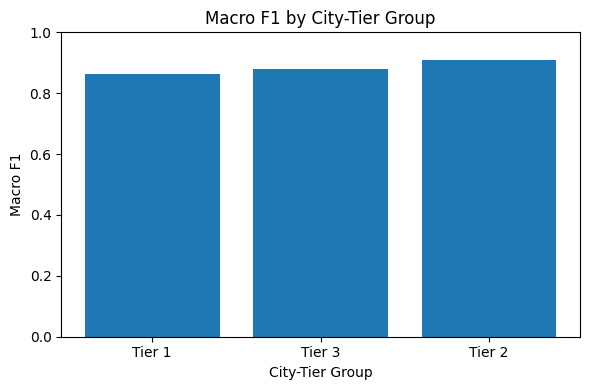

In [ ]:
#city tier visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(city_results["group"].astype(str), city_results["macro_f1"])
plt.title("Macro F1 by City-Tier Group")
plt.xlabel("City-Tier Group")
plt.ylabel("Macro F1")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

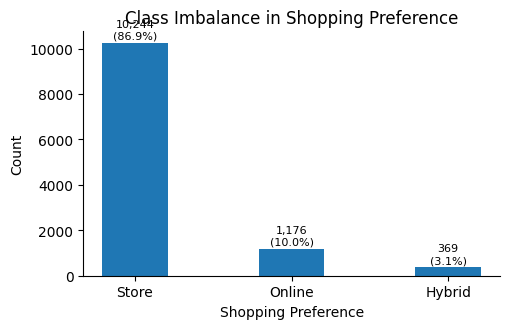

In [ ]:
import matplotlib.pyplot as plt

class_counts = df["shopping_preference"].value_counts()
class_pct = class_counts / class_counts.sum() * 100

plt.figure(figsize=(5.2, 3.4))
bars = plt.bar(
    class_counts.index.astype(str),
    class_counts.values,
    width=0.42
)

plt.title("Class Imbalance in Shopping Preference", fontsize=12)
plt.xlabel("Shopping Preference", fontsize=10)
plt.ylabel("Count", fontsize=10)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + class_counts.max()*0.01,
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()